# Moving Average Convergence/Divergence (MACD)

The MACD indicator (or "oscillator") is a collection of three time series calculated from historical price data, most often the closing price. These three series are: **the MACD series proper**, **the "signal" or "average" series**, and **the "divergence" series** which is the difference between the two.

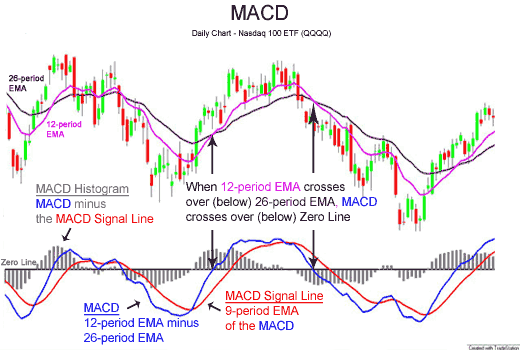

### Libraries

In [1]:
# yahoo finance
import yfinance as yf
# Data manipulation
import pandas as pd
import numpy as np
##Plots
import matplotlib.pyplot as plt
import seaborn as sns

### Loading Data

In [69]:
# MSFT data
df = yf.download('MSFT', period='max')

[*********************100%***********************]  1 of 1 completed


In [70]:
# check if it is multi-index
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.map(lambda x: x[0])

In [71]:
df=df.reset_index()
df

,Date,Close,High,Low,Open,Volume
0,1986-03-13,0.059253,0.061899,0.053963,0.053963,1031788800
1,1986-03-14,0.061369,0.062428,0.059253,0.059253,308160000
2,1986-03-17,0.062428,0.062957,0.061369,0.061369,133171200
3,1986-03-18,0.060840,0.062957,0.060311,0.062428,67766400
4,1986-03-19,0.059782,0.061369,0.059253,0.060840,47894400
...,...,...,...,...,...,...
10076,2026-03-12,401.859985,406.119995,401.709991,404.630005,27263900
10077,2026-03-13,395.549988,404.799988,394.250000,401.000000,26848000
10078,2026-03-16,399.950012,400.630005,394.790009,398.070007,27733700
10079,2026-03-17,399.410004,404.399994,397.750000,400.269989,26228300


### MACD

MACD signal line is equal to 9-perid EMA of MACD, and MACD is the result of EMA 12 - EMA 26.

In [72]:
ewma = pd.Series.ewm # function that offers exponential weigthed (EW) calculations

In [73]:
#computing ema 12
df['ema12'] = ewma(df['Close'], span=12).mean()
# computing ema 26
df['ema26'] = ewma(df['Close'], span=26).mean()
# cumputing MACD
df['MACD'] = df['ema26'] - df['ema12']
# Computing MACD signal
df['MACD_signal']=ewma(df['MACD'], span=9).mean()

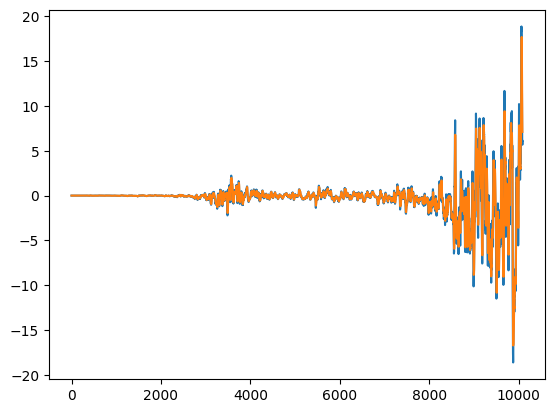

In [81]:
plt.plot(df['MACD'])
plt.plot(df['MACD_signal'])
plt.show()

### last 60 days MACD Plot

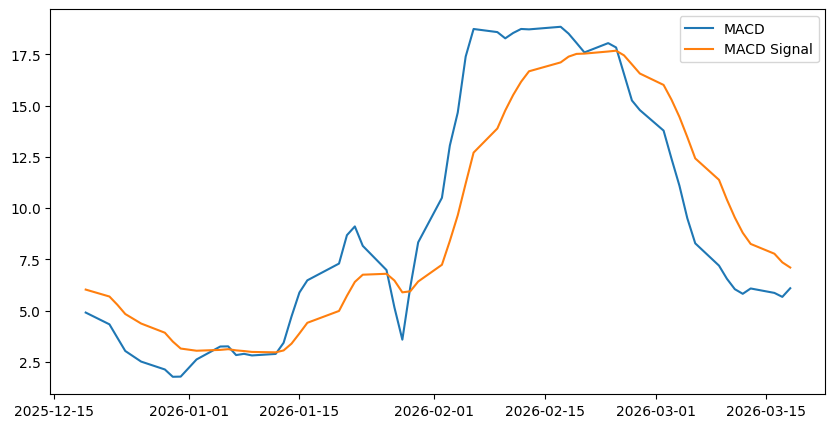

In [87]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'][-60:],df['MACD'][-60:], label= 'MACD')
plt.plot(df['Date'][-60:],df['MACD_signal'][-60:], label= 'MACD Signal')
plt.legend()
plt.show()

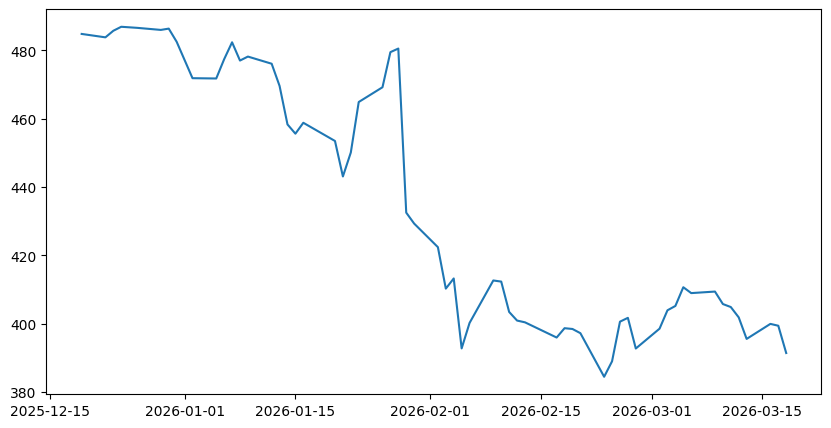

In [95]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'][-60:],df['Close'][-60:])